Using cpu device
Logging to ./ppo_tensorboard/
---------------------------------
| custom/            |          |
|    episode_reward  | 15       |
| rollout/           |          |
|    ep_len_mean     | 21.3     |
|    ep_rew_mean     | 21.3     |
| time/              |          |
|    fps             | 1608     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| custom/                 |             |
|    episode_reward       | 35          |
| rollout/                |             |
|    ep_len_mean          | 24.2        |
|    ep_rew_mean          | 24.2        |
| time/                   |             |
|    fps                  | 1145        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008558016 |

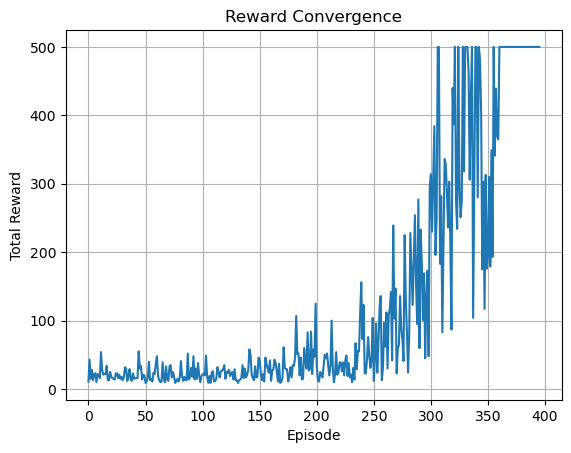

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.logger import configure
import os

# Fix OpenMP issue
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# TensorBoard log dir
log_dir = "./ppo_tensorboard/"
os.makedirs(log_dir, exist_ok=True)

# Custom callback for reward logging (both memory and TensorBoard)
class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.episode_reward = 0.0

    def _on_step(self) -> bool:
        reward = self.locals["rewards"][0]
        done = self.locals["dones"][0]

        self.episode_reward += reward

        if done:
            self.episode_rewards.append(self.episode_reward)
            self.logger.record("custom/episode_reward", self.episode_reward)
            self.episode_reward = 0.0

        return True

# Create environment
env = make_vec_env("CartPole-v1", n_envs=1)

# Create model with TensorBoard log
model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    tensorboard_log=log_dir,
    device="cuda"
)

# Optional: configure the logger for richer output (console + tensorboard)
new_logger = configure(log_dir, ["stdout", "tensorboard"])
model.set_logger(new_logger)

# Train with reward logger callback
reward_logger = RewardLogger()
model.learn(total_timesteps=50_000, callback=reward_logger)

# Plot rewards
plt.plot(reward_logger.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Convergence")
plt.grid(True)
plt.show()